# Telco Customer Churn Prediction
مشروع كامل للتنبؤ بانسحاب عملاء شركة الاتصالات باستخدام بيانات Blastchar من Kaggle

In [3]:
# ============================================================
# استيراد المكتبات الأساسية للتحليل والتصور
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score, ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE

import xgboost as xgb
import shap

# إعدادات عامة للرسوم البيانية
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42 


## Step 1: Data Loading & Initial Inspection
تحميل البيانات والفحص الأولي

In [4]:
# تحميل ملف البيانات من Kaggle (Blastchar Telco Customer Churn)
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# عرض أول 5 صفوف للتأكد من تحميل البيانات بشكل صحيح
print('Shape:', df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# معلومات عامة عن أنواع الأعمدة وعدد القيم غير المفقودة
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [ ]:
# إحصائيات وصفية للأعمدة الرقمية
df.describe(include='all').T
#هنا هو اتعامل مع(total charges) علي انه سترينج مش نمبر
#عمود ال churn (imbalanced)
#outlier مفيش

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# توزيع المتغير الهدف (Churn) - هل البيانات متوازنة؟
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100    #عشان نعرف النسبه

print('Churn Distribution:')
print(churn_counts)
print('\nPercentage:')
print(churn_pct.round(2))

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


## Step 2: Data Cleaning & Wrangling
تنظيف البيانات ومعالجة القيم المفقودة

In [ ]:
# نسخة من البيانات للعمل عليها دون تعديل الأصل
df_clean = df.copy()

# تحويل TotalCharges إلى رقمي (يوجد قيم فارغة مخزنة كنص)
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

# عدد القيم المفقودة بعد التحويل
print('Missing values after conversion:')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0]) #الجزء التانى دا عشان يطبع عمود التوتال لانه الوحيد اللي فيه ميسينج بدل ما كان هيطبع كل الاعمده

Missing values after conversion:
TotalCharges    11
dtype: int64


In [9]:
# حذف الصفوف التي تحتوي على قيم مفقودة (عادة عملاء جدد tenure=0)
df_clean = df_clean.dropna(subset=['TotalCharges']).reset_index(drop=True)
print('Shape after dropping missing:', df_clean.shape)

Shape after dropping missing: (7032, 21)


In [10]:
# حذف عمود customerID لأنه معرف فقط ولا يساعد في التنبؤ
df_clean = df_clean.drop(columns=['customerID'])

# ترميز المتغير الهدف: Yes=1 (انسحب), No=0 (بقي)
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

df_clean.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [ ]:
# التحقق من عدم وجود قيم مفقودة بعد التنظيف
print('Total missing values:', df_clean.isnull().sum().sum()) #فيه اتنين `sum()`؟** عشان نجيب **إجمالي القيم المفقودة في الداتا فريم كلها على بعضها (رقم واحد إجمالي)** بدل ما تطلع كقائمة لكل عمود
print('\nTarget distribution after encoding:')
print(df_clean['Churn'].value_counts(normalize=True).round(3))  # النورماليز عشان يطلع النسبه المئويه مش عدد القيم نفسه

Total missing values: 0

Target distribution after encoding:
Churn
0    0.734
1    0.266
Name: proportion, dtype: float64


## Step 3: EDA & Visualizations
التحليل الاستكشافي والرسوم البيانية

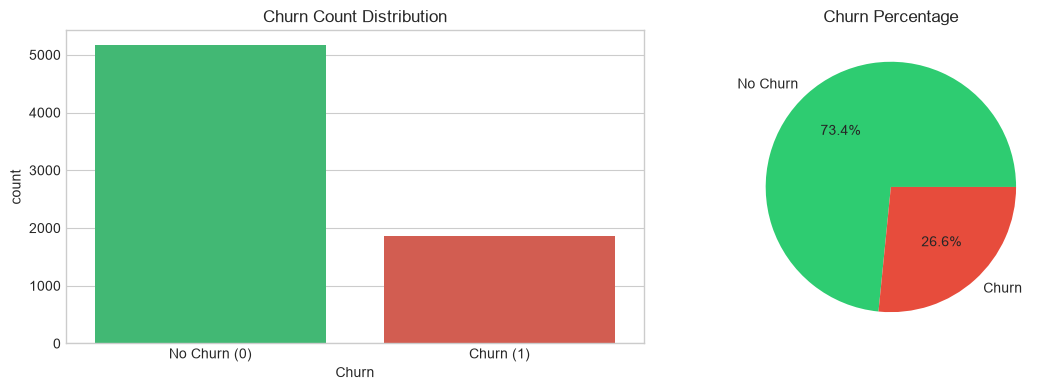

In [12]:
# رسم توازن/عدم توازن فئة Churn
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df_clean, x='Churn', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Count Distribution')
axes[0].set_xticklabels(['No Churn (0)', 'Churn (1)'])

df_clean['Churn'].value_counts(normalize=True).plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    labels=['No Churn', 'Churn'], colors=['#2ecc71', '#e74c3c']
)
axes[1].set_title('Churn Percentage')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

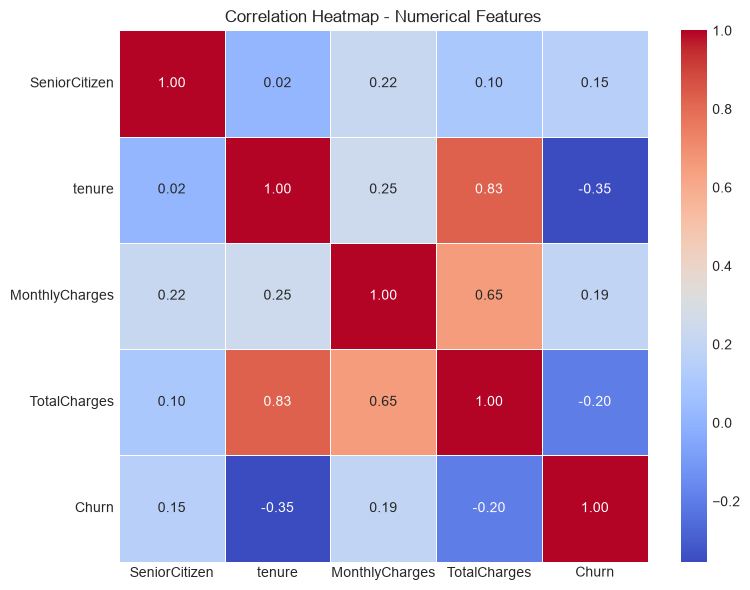

In [13]:
# خريطة ارتباط للأعمدة الرقمية
numeric_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap - Numerical Features')
plt.tight_layout()
plt.show()

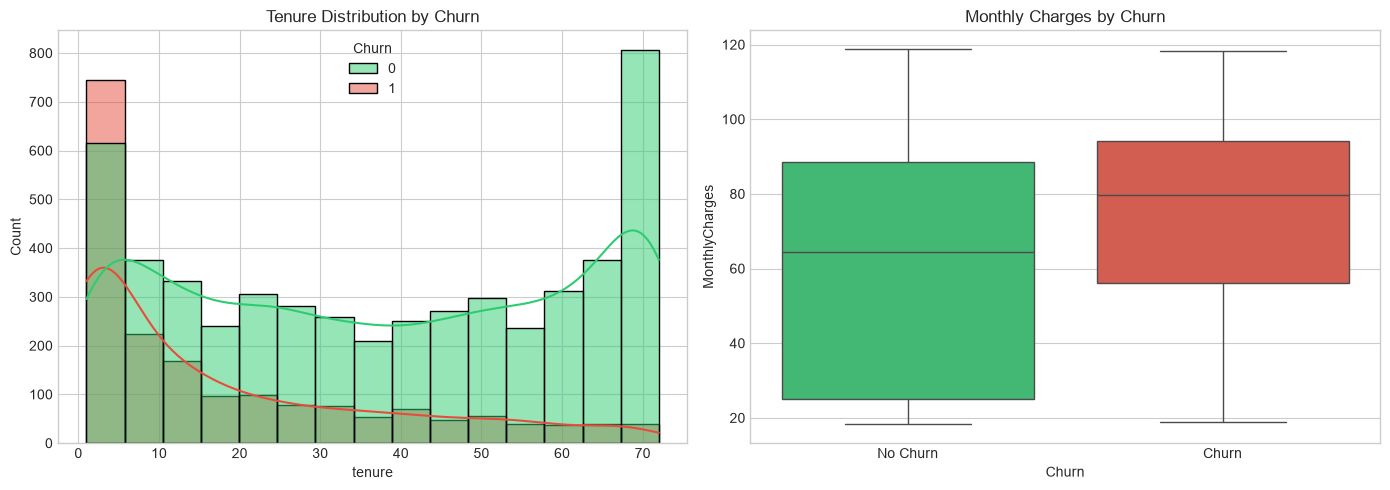

In [14]:
# توزيع tenure و MonthlyCharges حسب Churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_clean, x='tenure', hue='Churn', kde=True, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Tenure Distribution by Churn')

sns.boxplot(data=df_clean, x='Churn', y='MonthlyCharges', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Monthly Charges by Churn')
axes[1].set_xticklabels(['No Churn', 'Churn'])

plt.tight_layout()
plt.show()

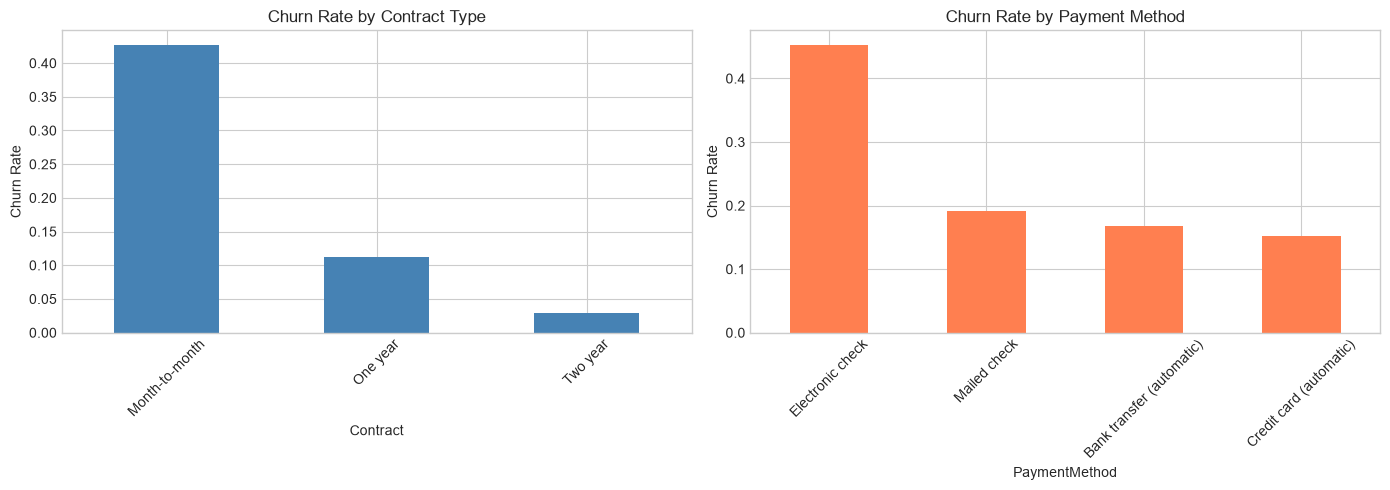

In [15]:
# معدل الانسحاب حسب نوع العقد وطريقة الدفع
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

contract_churn = df_clean.groupby('Contract')['Churn'].mean().sort_values(ascending=False)
contract_churn.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Churn Rate by Contract Type')
axes[0].set_ylabel('Churn Rate')
axes[0].tick_params(axis='x', rotation=45)

payment_churn = df_clean.groupby('PaymentMethod')['Churn'].mean().sort_values(ascending=False)
payment_churn.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Churn Rate by Payment Method')
axes[1].set_ylabel('Churn Rate')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Step 4: Preprocessing & Feature Engineering
المعالجة المسبقة وهندسة الميزات

In [ ]:
# فصل المتغير الهدف عن الميزات
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn']
#ChargeRatio (نسبة الفاتورة الحالية من الإجمالي)
#بتعرفك العميل دا "جديد" ولا "قديم"
#لو النسبة قريبة من 1 (زي أول صف عندك في الجدول) معناها العميل دا لسه في أولو وفي شهره الأول تقريباً، وده بيبقى معرض أكتر إنه يمشي لو التجربة عجبتوش.
X['ChargeRatio'] = X['MonthlyCharges'] / (X['TotalCharges'] + 1)

#AvgMonthlyCharge(متوسط اللي بيدفعه شهرياً)
#أحياناً الفاتورة الشهرية الحالية للعميل بتكون فيها عروض أو زادت فجأة
#بـ المتوسط دا بتقارني خطته الحالية بمتوسط اللي دفعه على مدار اشتراكه كله، فتعرفي هل باقته اتغيرت أو المصاريف زادت عليه فجأة فتسببت في إنه يفكر يسيب الشركة.
X['AvgMonthlyCharge'] = X['TotalCharges'] / (X['tenure'] + 1)

print('New features added: ChargeRatio, AvgMonthlyCharge')
X[['MonthlyCharges', 'TotalCharges', 'tenure', 'ChargeRatio', 'AvgMonthlyCharge']].head()

New features added: ChargeRatio, AvgMonthlyCharge


,MonthlyCharges,TotalCharges,tenure,ChargeRatio,AvgMonthlyCharge
0,29.85,29.85,1,0.967585,14.925000
1,56.95,1889.50,34,0.030124,53.985714
2,53.85,108.15,2,0.493358,36.050000
3,42.30,1840.75,45,0.022967,40.016304
4,70.70,151.65,2,0.463151,50.550000


In [17]:
# تحديد الأعمدة الرقمية والفئوية
numeric_features = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
                    'ChargeRatio', 'AvgMonthlyCharge']
categorical_features = [col for col in X.columns if col not in numeric_features]

print('Numerical features:', numeric_features)
print('\nCategorical features:', categorical_features)

Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'ChargeRatio', 'AvgMonthlyCharge']

Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [ ]:
# One-Hot Encoding للفئات + StandardScaler للأرقام
# ترميز الفئات يدوياً (One-Hot Encoding) 
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# تطبيق StandardScaler على الأعمدة الرقمية فقط
scaler = StandardScaler()
X_encoded[numeric_features] = scaler.fit_transform(X_encoded[numeric_features])

print('Shape after encoding & scaling:', X_encoded.shape)
X_encoded.head()

Shape after encoding & scaling: (7032, 32)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,ChargeRatio,AvgMonthlyCharge,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-0.440327,-1.280248,-1.161694,-0.994194,2.961266,-1.447223,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,-0.440327,0.064303,-0.260878,-0.173740,-0.454807,-0.167059,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,-0.440327,-1.239504,-0.363923,-0.959649,1.233199,-0.754879,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,-0.440327,0.512486,-0.747850,-0.195248,-0.480887,-0.624888,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,-0.440327,-1.239504,0.196178,-0.940457,1.123127,-0.279660,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


## Step 5: Handling Imbalance & Splitting
معالجة عدم التوازن وتقسيم البيانات

In [19]:
# تقسيم Train/Test مع stratify للحفاظ على نسب Churn
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Train size:', X_train.shape[0])
print('Test size:', X_test.shape[0])
print('\nTrain Churn rate:', y_train.mean().round(3))
print('Test Churn rate:', y_test.mean().round(3))

Train size: 5625
Test size: 1407

Train Churn rate: 0.266
Test Churn rate: 0.266


In [ ]:
# تطبيق SMOTE على بيانات التدريب فقط لموازنة الفئات
#عندنا مشكله ان عدد اللي مش هيمشو اكبر اربع اضعاف من اللي هيمشو ف هنزود في عدد اللي هيمشو عشان نوازن
smote = SMOTE(random_state=RANDOM_STATE)     #هنزود بينات وهميه في ال x,y training 
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print('Before SMOTE - Train Churn distribution:')
print(y_train.value_counts().to_dict())
print('\nAfter SMOTE - Train Churn distribution:')
print(pd.Series(y_train_resampled).value_counts().to_dict())

Before SMOTE - Train Churn distribution:
{0: 4130, 1: 1495}

After SMOTE - Train Churn distribution:
{0: 4130, 1: 4130}


## Step 6: Model Building & Training
بناء وتدريب النماذج

In [21]:
# نموذج 1: Logistic Regression (baseline سريع وقابل للتفسير)
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_model.fit(X_train_resampled, y_train_resampled)

print('Logistic Regression - Training completed.')

Logistic Regression - Training completed.


In [ ]:
# نموذج 2: Random Forest (قوي مع البيانات المختلطة)
rf_model = RandomForestClassifier(
    n_estimators=100,          #عدد الاشجار
    max_depth=10,
    class_weight='balanced',  # بديل/additional لـ SMOTE
    random_state=RANDOM_STATE,
    n_jobs=-1         #بيخلي الجهاز يشتغل بأقصى سرعة ممكنة عبر استغلال كل أنوية المعالج
)
rf_model.fit(X_train, y_train)  # RF يُدرّب على البيانات الأصلية + class_weight

print('Random Forest - Training completed.')

Random Forest - Training completed.


In [ ]:
# نموذج 3: XGBoost (أداء عالي غالباً في مسائل التصنيف)
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # موازنة الفئات
    random_state=RANDOM_STATE,
    eval_metric='logloss',  #دالة التقييم المستخدمة لحساب نسبة الخطأ أثناء التدريب.
    use_label_encoder=False
)
xgb_model.fit(X_train, y_train)

print('XGBoost - Training completed.')

XGBoost - Training completed.


## Step 7: Model Evaluation & Business Interpretation
تقييم النماذج والتفسير التجاري

In [ ]:
# دالة مساعدة لتقييم أي نموذج على بيانات الاختبار
def evaluate_model(model, X_test, y_test, model_name):
    """تقييم النموذج: Confusion Matrix + Classification Report + ROC-AUC"""
    y_pred = model.predict(X_test)    #بيطلع التوقع النهائي المباشر (إما 0 العميل هيفضل، أو 1 العميل هيسيب الشركة).
    y_proba = model.predict_proba(X_test)[:, 1]  #بيطلع نسبة الاحتمالية (Probability) إن العميل يسيب الشركة (قيم بين 0 و 1)

    print('=' * 60)
    print(f'Model: {model_name}')
    print('=' * 60)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

    # Classification Report - التركيز على Recall (اكتشاف المنسحبين) و Precision
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
    print('Business Note: Recall for Churn = % of actual churners we catch (retention campaigns)')
    print('Business Note: Precision for Churn = % of flagged customers who actually churn')

    # ROC-AUC
    auc = roc_auc_score(y_test, y_proba)
    print(f'\nROC-AUC Score: {auc:.4f}')

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate (Recall)')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend()
    plt.show()

    return y_pred, y_proba

Model: Logistic Regression


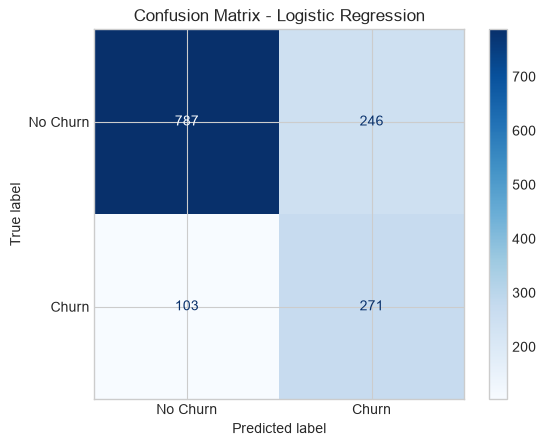


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.88      0.76      0.82      1033
       Churn       0.52      0.72      0.61       374

    accuracy                           0.75      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.79      0.75      0.76      1407

Business Note: Recall for Churn = % of actual churners we catch (retention campaigns)
Business Note: Precision for Churn = % of flagged customers who actually churn

ROC-AUC Score: 0.8267


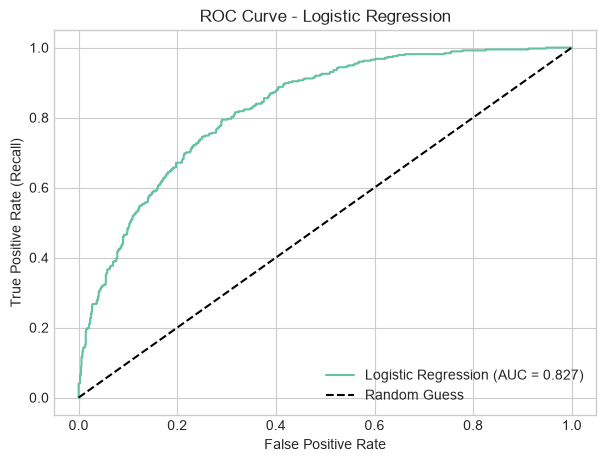

In [25]:
# تقييم Logistic Regression
lr_pred, lr_proba = evaluate_model(lr_model, X_test, y_test, 'Logistic Regression')

Model: Random Forest


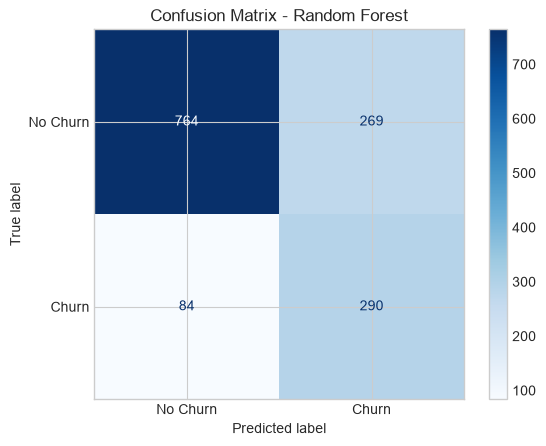


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.74      0.81      1033
       Churn       0.52      0.78      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407

Business Note: Recall for Churn = % of actual churners we catch (retention campaigns)
Business Note: Precision for Churn = % of flagged customers who actually churn

ROC-AUC Score: 0.8342


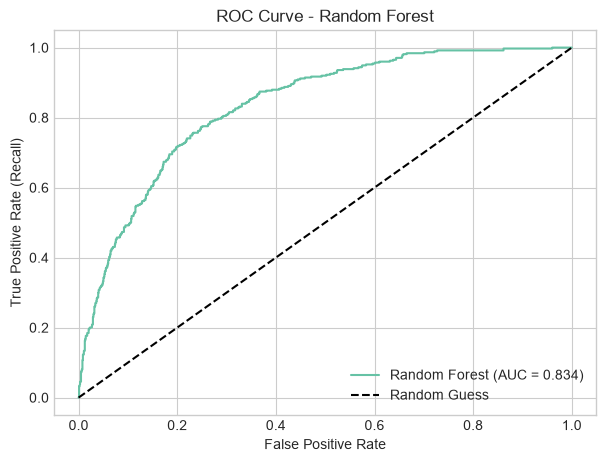

In [26]:
# تقييم Random Forest
rf_pred, rf_proba = evaluate_model(rf_model, X_test, y_test, 'Random Forest')

Model: XGBoost


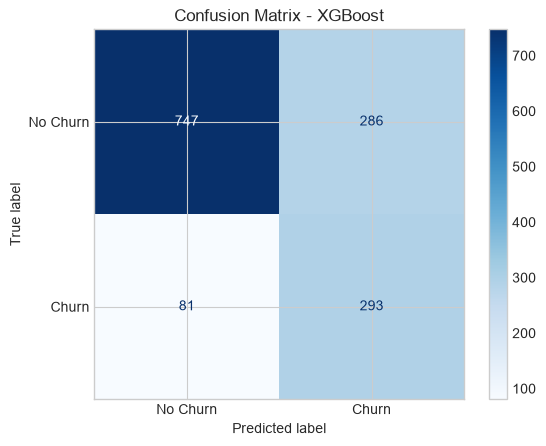


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1033
       Churn       0.51      0.78      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.74      0.75      1407

Business Note: Recall for Churn = % of actual churners we catch (retention campaigns)
Business Note: Precision for Churn = % of flagged customers who actually churn

ROC-AUC Score: 0.8348


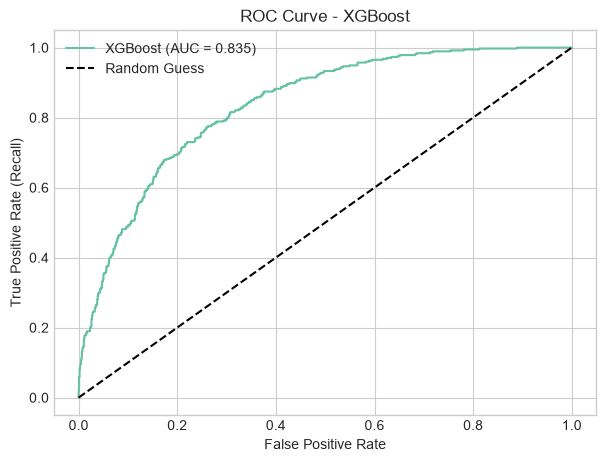

In [27]:
# تقييم XGBoost
xgb_pred, xgb_proba = evaluate_model(xgb_model, X_test, y_test, 'XGBoost')

In [28]:
# مقارنة سريعة بين النماذج الثلاثة
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_proba),
        roc_auc_score(y_test, rf_proba),
        roc_auc_score(y_test, xgb_proba)
    ]
})
comparison = comparison.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print('Model Comparison (ROC-AUC on Test Set):')
print(comparison.to_string(index=False))

Model Comparison (ROC-AUC on Test Set):
              Model  ROC-AUC
            XGBoost 0.834794
      Random Forest 0.834151
Logistic Regression 0.826707


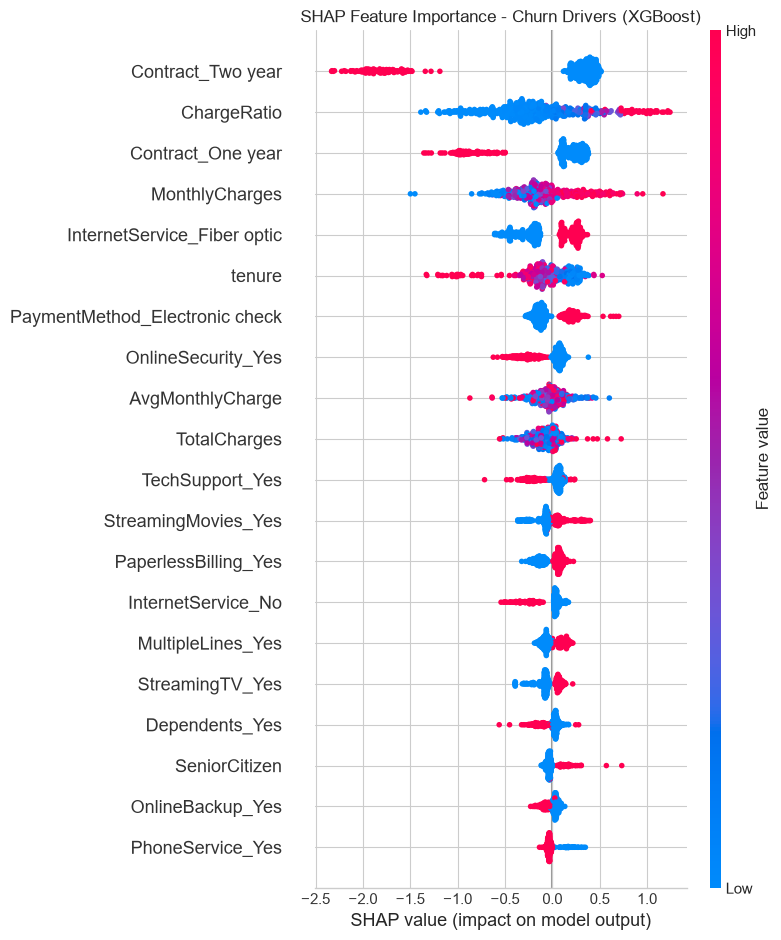

In [ ]:
# SHAP: شرح أهم الميزات المؤثرة في قرار الانسحاب (باستخدام XGBoost)
#وظيفتها الأساسية هي "فتح الصندوق الأسود" (Black Box) لنموذج المعقد زي XGBoost، 
# عشان تفهمي بالضبط ليه النموذج أخد القرار ده، وايه هي أهم الميزات (Features) اللي بتخلي العميل يسيب الشركة أو يفضل فيها.
# نأخذ عينة صغيرة من الاختبار لتسريع الحساب
X_test_sample = X_test.sample(n=min(500, len(X_test)), random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_sample)

# رسم أهمية الميزات (Summary Plot)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title('SHAP Feature Importance - Churn Drivers (XGBoost)')
plt.tight_layout()
plt.show()

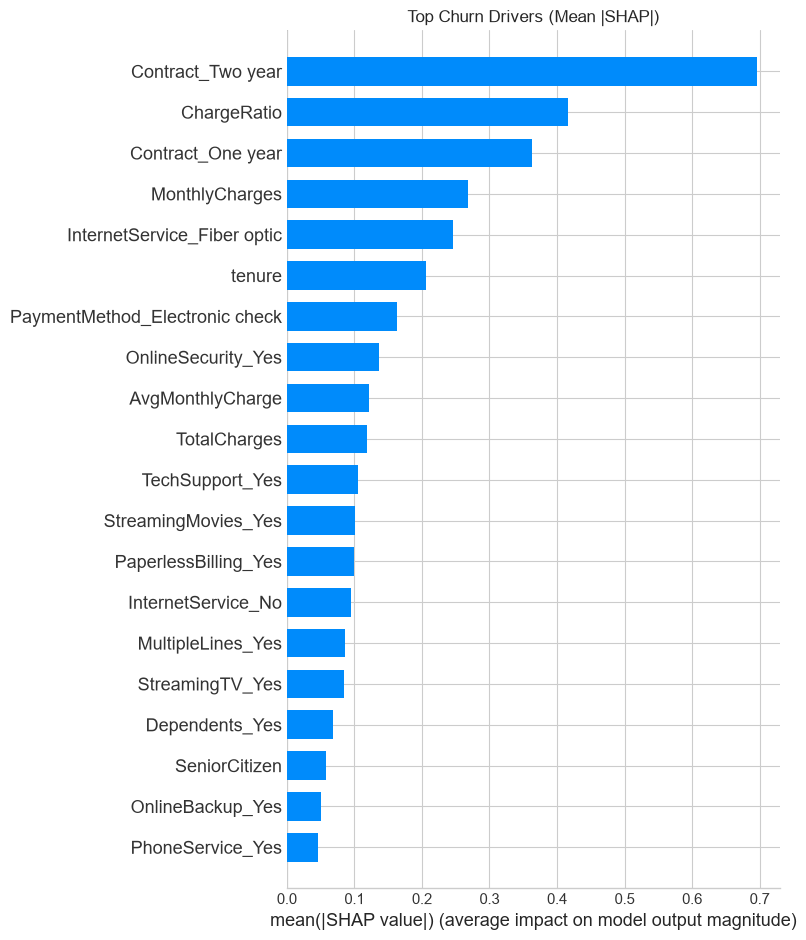

In [30]:
# SHAP Bar Plot - ترتيب الميزات حسب التأثير المتوسط
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, plot_type='bar', show=False)
plt.title('Top Churn Drivers (Mean |SHAP|)')
plt.tight_layout()
plt.show()

In [31]:
# ============================================================
# ملخص تجاري (Business Interpretation)
# ============================================================
print('=' * 60)
print('BUSINESS INSIGHTS SUMMARY')
print('=' * 60)
print('''
1. Recall (Churn) مهم جداً: كل عميل منسحب لم نكتشفه = خسارة إيرادات.
2. Precision (Churn) يحدد تكلفة حملات الاحتفاظ: تنبيهات كاذبة = عروض غير ضرورية.
3. من EDA: العقود الشهرية و Electronic check مرتبطة بمعدل انسحاب أعلى.
4. tenure منخفض + MonthlyCharges مرتفع = إشارات خطر مبكرة.
5. استخدم SHAP لتحديد العملاء عاليي الخطورة وتخصيص عروض الاحتفاظ.
''')

BUSINESS INSIGHTS SUMMARY

1. Recall (Churn) مهم جداً: كل عميل منسحب لم نكتشفه = خسارة إيرادات.
2. Precision (Churn) يحدد تكلفة حملات الاحتفاظ: تنبيهات كاذبة = عروض غير ضرورية.
3. من EDA: العقود الشهرية و Electronic check مرتبطة بمعدل انسحاب أعلى.
4. tenure منخفض + MonthlyCharges مرتفع = إشارات خطر مبكرة.
5. استخدم SHAP لتحديد العملاء عاليي الخطورة وتخصيص عروض الاحتفاظ.

